<a href="https://colab.research.google.com/github/Manuel-Carreno/forecasting-parcial/blob/main/02_Parcial_Forecasting_Manuel_Carre%C3%B1o_Esteban_Sequeda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Forecasting de revenue - Hapy Cow Ice Cream


## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---


## Contexto e introducción

En el caso de Happy Cow Ice Cream, se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Debido al alto nivel de ruido y variabilidad en la información diaria, el análisis se enfocará en construir un forecast semanal, permitiendo identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes, como la limitada cantidad de datos disponibles y la influencia de factores externos en la demanda, lo que hace necesario complementar el modelado con un análisis exploratorio cuidadoso 🧠.

## 🧩 Enunciado

Como consultor externo, se le solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes, generando pronósticos **semanales (cuatro semanas adelante)**. Los datos se encuentran en el archivo `ice_cream_data_daily.csv`, que incluye:

- **Product**
- **Date_clean**
- **Revenue**

El objetivo es producir pronósticos confiables que apoyen la planificación, reduzcan el desperdicio y mejoren la eficiencia operativa. 📊🤝


In [76]:
import sys
!{sys.executable} -m pip install statsforecast hierarchicalforecast

# Standard library imports
import inspect
import json
import os
import re
import warnings
import webbrowser

# Data handling libraries
import numpy as np
import pandas as pd

# Metrics for model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Visualization libraries
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display
from plotly.subplots import make_subplots

# Forecasting libraries (StatsForecast / Nixtla)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta, SeasonalNaive
from statsforecast.utils import ConformalIntervals

# Hierarchical Forecasting libraries (Nixtla)
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.utils import aggregate

# General settings
warnings.filterwarnings("ignore")

data = pd.read_csv("ice_cream_data_daily.csv", delimiter=',', encoding="utf8")
data.head(100)

,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0
...,...,...,...
95,1 Topping,2017-07-05,0.0
96,1 Topping,2017-07-06,0.0
97,1 Topping,2017-07-07,0.0
98,1 Topping,2017-07-08,0.0


Esto se hizo con la finalidad de revisar si hay datos faltantes para cada hora es importante saber que todos los sabores estuvieran

# ✅ Criterios de evaluación – Descripción

1) **Exploración y limpieza de los datos**  
Realiza una exploración clara de la serie y sus variables (tendencias, estacionalidad, valores atípicos, faltantes). Limpia y estandariza formatos (fechas, unidades, precios) y deja trazabilidad de las decisiones tomadas para garantizar un conjunto de datos listo para modelar.

2) **Modelo “base”, métrica y separación temporal**  
Implementa un modelo base razonable para tu problema (p. ej., media móvil) y evalúalo con una métrica coherente con el negocio (MAE, RMSE o MAPE). Separa correctamente entrenamiento y test respetando la temporalidad, evitando cualquier fuga de información.

3) **Modelo avanzado para mejorar predicciones**  
Construye un modelo más sofisticado (ARIMA/SARIMA/SARIMAX, Prophet, ETS o un enfoque de ML con rasgos temporales/exógenas) y justifica su elección. Demuestra mejora frente al modelo base usando la misma ventana de evaluación y la misma métrica.

4) **Uso del modelo: predicción 4 semanas adelante**  
Selecciona un modelo ganador y genera un pronóstico operativo a **4 semanas** (multi‐paso). Entrega las predicciones en una tabla y un gráfico del horizonte, idealmente con intervalos de confianza y una breve guía de cómo reproducir el proceso.


### Punto 1

In [52]:
conteo_productos = (
    data["Product"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False, sort=False)
)

print(conteo_productos.to_string())

Product
1 Topping                           183
1 Topping Staff                     183
1 Toppings St                       183
3 Topping                           183
3 Topping Staff                     183
Apricot                             183
Apricot ST                          183
Apricot Staff                       183
Asia Research Free Scoop            183
Banana Caramel  /                   183
Banana Caramel St                   183
Banana Staff                        183
Building Promotion                  183
Chai Tea                            183
Chai Tea Staff                      183
Chai Tea st                         183
Cherry Alm Staff                    183
Cherry Almond                       183
Cherry Almond Fudge st              183
Chocoate Cookies                    183
Chocolate                           183
Chocolate St                        183
Chocolate Staff                     183
Coffee                              183
Coffee  St                      

#### Nota
Esto se hace con la finalidad de saber sin hay datos faltantes en la serie de tiempo

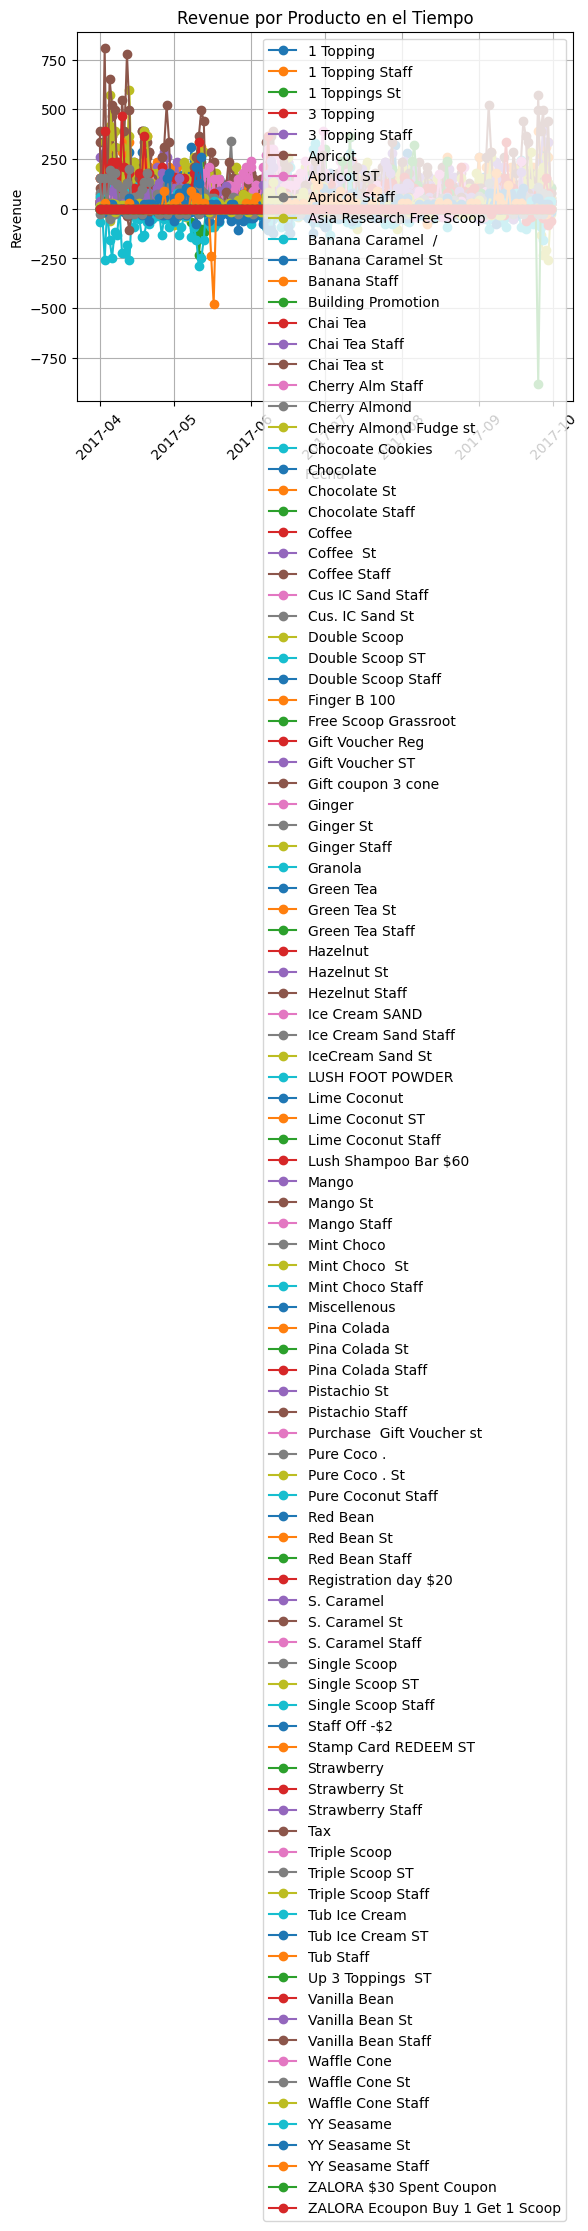

In [53]:
data["Date_clean"] = pd.to_datetime(data["Date_clean"])

for producto in data["Product"].unique():
    filtro = data[data["Product"] == producto]
    plt.plot(filtro["Date_clean"], filtro["Revenue"], marker="o", label=producto)

plt.title("Revenue por Producto en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Nota
Se realizó un *plot* de las gráficas con el fin de analizar su comportamiento; sin embargo, debido a la alta cantidad de categorías y subcategorías, fue necesario aplicar un tratamiento previo de los datos.


In [54]:


# 1. COPIA Y LIMPIEZA INICIAL

df = data.copy()

df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Product"] = df["Product"].astype(str).str.strip()
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(subset=["Date_clean", "Product", "Revenue"])

df["Product_original"] = df["Product"]

# 2. DICCIONARIO COMPLETO DE PRODUCTOS

EXCEPCIONES_BASE = {
    "1 topping": "1 Topping",
    "1 toppings": "1 Topping",
    "3 topping": "3 Topping",
    "3 toppings": "3 Topping",
    "banana caramel": "Banana Caramel",
    "banana": "Banana Caramel",
    "apricot": "Apricot",
    "chai tea": "Chai Tea",
    "cherry almond": "Cherry Almond",
    "cherry almond fudge": "Cherry Almond Fudge",
    "chocoate cookies": "Chocolate Cookies",
    "chocolate": "Chocolate",
    "coffee": "Coffee",
    "cus ic sand": "Cus IC Sand",
    "cus. ic sand": "Cus IC Sand",
    "double scoop": "Double Scoop",
    "green tea": "Green Tea",
    "hazelnut": "Hazelnut",
    "hezelnut": "Hazelnut",
    "ice cream sand": "Ice Cream Sand",
    "icecream sand": "Ice Cream Sand",
    "lime coconut": "Lime Coconut",
    "mango": "Mango",
    "mint choco": "Mint Choco",
    "miscellenous": "Miscellenous",
    "pina colada": "Pina Colada",
    "pistachio": "Pistachio",
    "pure coco": "Pure Coconut",
    "pure coconut": "Pure Coconut",
    "red bean": "Red Bean",
    "s. caramel": "S. Caramel",
    "single scoop": "Single Scoop",
    "strawberry": "Strawberry",
    "triple scoop": "Triple Scoop",
    "tub": "Tub Ice Cream",
    "tub ice cream": "Tub Ice Cream",
    "up 3 toppings": "Up 3 Toppings",
    "vanilla bean": "Vanilla Bean",
    "waffle cone": "Waffle Cone",
    "yy seasame": "YY Seasame"
}

# 3. FUNCIÓN PARA LIMPIAR PRODUCTO Y CATEGORÍA


def limpiar_producto(prod):
    s = str(prod).strip()

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*/\s*$", "", s)
    s = re.sub(r"\s*\.\s*$", "", s)

    if re.search(r"\bstaff$", s, flags=re.IGNORECASE):
        categoria = "Staff"
        base = re.sub(r"\bstaff$", "", s, flags=re.IGNORECASE).strip()

    elif re.search(r"\bst$", s, flags=re.IGNORECASE):
        categoria = "Student"
        base = re.sub(r"\bst$", "", s, flags=re.IGNORECASE).strip()

    else:
        categoria = "Publico general"
        base = s.strip()

    base = re.sub(r"\s+", " ", base)
    base = re.sub(r"\s*/\s*$", "", base)
    base = re.sub(r"\s*\.\s*$", "", base).strip()

    clave = base.lower()
    base_final = EXCEPCIONES_BASE.get(clave, base)

    producto_mostrado = f"{base_final} - {categoria}"

    return pd.Series([base_final, categoria, producto_mostrado])

df[["Product_base", "Categoria", "Product_limpio"]] = df["Product"].apply(limpiar_producto)
df["Product"] = df["Product_limpio"]

#### Nota
Este bloque de código es fundamental para la limpieza de datos y la creación de un diccionario que permita la unificación de la información y facilite su comprensión.


In [55]:


# 1. USAR TODOS LOS PRODUCTOS

df_todos = df.copy()

# 2. AGRUPAR POR SEMANA, PRODUCTO Y CATEGORÍA

df_grouped = (
    df_todos
    .groupby([
        pd.Grouper(key="Date_clean", freq="W-SUN"),
        "Product_base",
        "Categoria"
    ], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Categoria", "Date_clean"])
)

df_grouped = df_grouped.rename(columns={"Date_clean": "Semana"})

# 3. TOTAL SEMANAL POR PRODUCTO

df_total_sabor = (
    df_grouped
    .groupby(["Semana", "Product_base"], as_index=False)["Revenue"]
    .sum()
    .sort_values(["Product_base", "Semana"])
)

df_total_sabor["Categoria"] = "Total categoria"

# 4. TOTAL SEMANAL GENERAL DE TODOS LOS PRODUCTOS

df_total_general = (
    df_grouped
    .groupby(["Semana"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Semana")
)

# 5. DATAFRAME FINAL PARA PREDICCIÓN GENERAL

df_final_agrupado = df_total_general.copy()
df_final_agrupado.columns = ["Semana", "Revenue_Total"]

print("Agrupación semanal completa: todos los productos")
display(df_final_agrupado)


# 6. DATAFRAME SEMANAL DETALLADO POR PRODUCTO


df_semanal_por_producto = df_total_sabor.copy()
df_semanal_por_producto = df_semanal_por_producto.rename(
    columns={"Product_base": "Producto", "Revenue": "Revenue_Total"}
)

print("Agrupación semanal por producto")
display(df_semanal_por_producto)

# 7. GRÁFICO INTERACTIVO

sabores = sorted(df_grouped["Product_base"].unique())
categorias_base = ["Publico general", "Student", "Staff"]

fig = go.Figure()
trace_map = {}

for idx, sabor in enumerate(sabores):
    trace_map[sabor] = {}

    for categoria in categorias_base:
        temp = df_grouped[
            (df_grouped["Product_base"] == sabor) &
            (df_grouped["Categoria"] == categoria)
        ].sort_values("Semana")

        fig.add_trace(
            go.Scatter(
                x=temp["Semana"],
                y=temp["Revenue"],
                mode="lines+markers",
                name=categoria,
                visible=(idx == 0)
            )
        )

        trace_map[sabor][categoria] = len(fig.data) - 1

    temp_total = df_total_sabor[
        df_total_sabor["Product_base"] == sabor
    ].sort_values("Semana")

    fig.add_trace(
        go.Scatter(
            x=temp_total["Semana"],
            y=temp_total["Revenue"],
            mode="lines+markers",
            name="Total producto",
            visible=False,
            line=dict(dash="dash")
        )
    )

    trace_map[sabor]["Total producto"] = len(fig.data) - 1

fig.add_trace(
    go.Scatter(
        x=df_total_general["Semana"],
        y=df_total_general["Revenue"],
        mode="lines+markers",
        name="Total general",
        visible=False,
        line=dict(width=4)
    )
)

global_trace_index = len(fig.data) - 1

titulo_inicial = (
    f"Revenue semanal de {sabores[0]} por categoría"
    if sabores
    else "Revenue semanal por categoría"
)

fig.update_layout(
    title=titulo_inicial,
    xaxis_title="Semana",
    yaxis_title="Revenue",
    template="plotly_white",
    hovermode="x unified",
    width=1450,
    height=850,
    margin=dict(t=120, r=40, l=60, b=60),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

# 8. EXPORTAR GRÁFICO A HTML

grafico_html = pio.to_html(
    fig,
    full_html=False,
    include_plotlyjs="cdn",
    div_id="grafico_sabores"
)

options_html = "\n".join(
    [f'<option value="{sabor}">{sabor}</option>' for sabor in sabores]
)

html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <title>Gráfico semanal de productos</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
        }}
        .barra-controles {{
            display: flex;
            gap: 12px;
            align-items: center;
            flex-wrap: wrap;
            margin-bottom: 16px;
        }}
        .barra-controles label {{
            font-weight: bold;
        }}
        .barra-controles select,
        .barra-controles button {{
            padding: 8px 12px;
            font-size: 14px;
            cursor: pointer;
        }}
    </style>
</head>
<body>

<div class="barra-controles">
    <label for="selectorSabor">Producto:</label>
    <select id="selectorSabor">
        {options_html}
    </select>

    <button id="btnTotalCategoria">Mostrar total producto</button>
    <button id="btnTotalGeneral">Mostrar total general</button>
</div>

{grafico_html}

<script>
    const sabores = {json.dumps(sabores, ensure_ascii=False)};
    const traceMap = {json.dumps(trace_map, ensure_ascii=False)};
    const globalTraceIndex = {global_trace_index};

    const gd = document.getElementById("grafico_sabores");
    const selector = document.getElementById("selectorSabor");
    const btnTotalCategoria = document.getElementById("btnTotalCategoria");
    const btnTotalGeneral = document.getElementById("btnTotalGeneral");

    let saborActual = sabores.length > 0 ? sabores[0] : null;
    let totalCategoriaVisible = false;
    let vistaTotalGeneral = false;

    function actualizarVista() {{
        const visibles = Array(gd.data.length).fill(false);

        if (vistaTotalGeneral) {{
            visibles[globalTraceIndex] = true;

            Plotly.restyle(gd, "visible", visibles);
            Plotly.relayout(gd, {{
                title: "Revenue semanal total general: todos los productos"
            }});

            selector.disabled = true;
            btnTotalCategoria.disabled = true;
            btnTotalGeneral.textContent = "Volver al detalle";
            return;
        }}

        visibles[traceMap[saborActual]["Publico general"]] = true;
        visibles[traceMap[saborActual]["Student"]] = true;
        visibles[traceMap[saborActual]["Staff"]] = true;

        if (totalCategoriaVisible) {{
            visibles[traceMap[saborActual]["Total producto"]] = true;
        }}

        Plotly.restyle(gd, "visible", visibles);

        Plotly.relayout(gd, {{
            title: totalCategoriaVisible
                ? `Revenue semanal de ${{saborActual}} por categoría + total producto`
                : `Revenue semanal de ${{saborActual}} por categoría`
        }});

        selector.disabled = false;
        btnTotalCategoria.disabled = false;

        btnTotalCategoria.textContent = totalCategoriaVisible
            ? "Ocultar total producto"
            : "Mostrar total producto";

        btnTotalGeneral.textContent = "Mostrar total general";
    }}

    selector.addEventListener("change", function() {{
        saborActual = this.value;
        vistaTotalGeneral = false;
        actualizarVista();
    }});

    btnTotalCategoria.addEventListener("click", function() {{
        if (vistaTotalGeneral) return;
        totalCategoriaVisible = !totalCategoriaVisible;
        actualizarVista();
    }});

    btnTotalGeneral.addEventListener("click", function() {{
        vistaTotalGeneral = !vistaTotalGeneral;
        actualizarVista();
    }});

    actualizarVista();
</script>

</body>
</html>
"""

nombre_archivo = "grafico_productos_semanal.html"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"Archivo generado: {nombre_archivo}")

webbrowser.open("file://" + os.path.abspath(nombre_archivo))

Agrupación semanal completa: todos los productos


,Semana,Revenue_Total
0,2017-04-02,2348.00000
1,2017-04-09,15125.00000
2,2017-04-16,11540.00000
3,2017-04-23,14016.99999
4,2017-04-30,11172.99998
5,2017-05-07,10163.00000
6,2017-05-14,11287.00000
7,2017-05-21,8191.99998
8,2017-05-28,7190.99998
9,2017-06-04,7377.99996


Agrupación semanal por producto


,Semana,Producto,Revenue_Total,Categoria
0,2017-04-02,1 Topping,0.0,Total categoria
51,2017-04-09,1 Topping,6.0,Total categoria
102,2017-04-16,1 Topping,21.0,Total categoria
153,2017-04-23,1 Topping,46.0,Total categoria
204,2017-04-30,1 Topping,20.0,Total categoria
...,...,...,...,...
1172,2017-09-03,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria
1223,2017-09-10,ZALORA Ecoupon Buy 1 Get 1 Scoop,-26.0,Total categoria
1274,2017-09-17,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria
1325,2017-09-24,ZALORA Ecoupon Buy 1 Get 1 Scoop,0.0,Total categoria


Archivo generado: grafico_productos_semanal.html


False

#### 🗒️ Abrir grafico_sabores.html
##### El mas importante es   "Mint Choco" y "S. Caramel",

Este grafico es la repesentacion visual del las ganacias totales por porducto vendido, agrupando las ganacias y los costos, ccon los botones se puede ver el costo total y los costos por categoria st (student), staff y publico generla

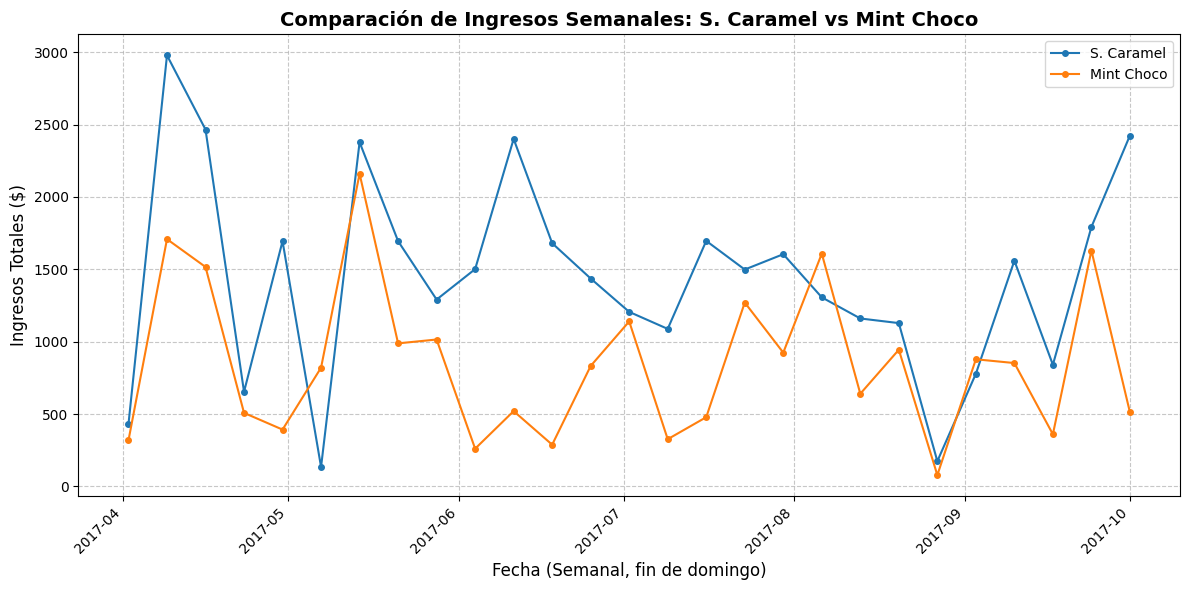

In [56]:

df_weekly_product_revenue = df_semanal_por_producto[df_semanal_por_producto['Categoria'] == 'Total categoria'].copy()

top_products_for_comparison = ['S. Caramel', 'Mint Choco']

plot_data = {}
for product_name in top_products_for_comparison:
    sub_df = df_weekly_product_revenue[df_weekly_product_revenue['Producto'] == product_name].copy()
    plot_data[product_name] = sub_df.set_index('Semana')['Revenue_Total']

plt.figure(figsize=(12, 6))

for product_name, series in plot_data.items():
    plt.plot(series.index, series.values, label=product_name, marker='o', markersize=4, linewidth=1.5)

plt.title('Comparación de Ingresos Semanales: S. Caramel vs Mint Choco', fontsize=14, fontweight='bold')
plt.xlabel('Fecha (Semanal, fin de domingo)', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Hallazgos observados

* No tiene sentido que **One Scoop**, **Dolce Scoop** y **Triple Scoop** aparezcan como **valores módulo**, porque eso invierte los datos a positivos y puede distorsionar el análisis.

* En **Stamp Card** se observan **pérdidas**.

* **Ice Cream Sand** presenta **valores nulos** desde el **3 de junio** hasta el **25 de junio**.

* **Avellana** muestra una **caída** desde el **20 de mayo** hasta el **13 de junio**.

* **Jengibre**, como se mencionaba en el texto por las creencias chinas, **sube** desde el **13 de mayo** hasta el **31 de mayo**; luego **vuelve a caer**; y entre el **12 de julio** y el **9 de agosto** **presenta otro incremento**.

* **Red Bean** tiene un **comportamiento similar al de productos calientes**, ya que entre el **30 de mayo** y el **21 de junio** se comporta de esa manera.

* **Pistacho** **sube** desde el **5 de junio** hasta el **10 de junio**.

* **Lime Coconut** **sube** desde el **10 de julio** hasta el **29 de julio**; allí presenta una **leve caída**; luego **vuelve a subir** el **10 de agosto**; alcanza su **pico el 19 de agosto**; y después **desciende** hasta el **28 de agosto**.

* **Coffee** **sube** desde el **8 de junio** hasta el **27 de junio** y presenta **valores nulos** desde el **27 de junio** hasta el **6 de julio**.



### Punto 2

### ✅ Identificación Modelo Base
Primero identificamos los productos que mas se venden


In [57]:
top_productos = (data.groupby('Product')['Revenue'].sum().sort_values(ascending=False))
print(top_productos.head(10))

Product
S. Caramel St       25201.79338
Mint Choco  St      14861.04761
Mango St            14128.30953
Chocolate St        13906.33333
Pure Coco . St      13570.33333
Strawberry St       11541.50000
S. Caramel Staff    10226.21211
Chai Tea st          9952.83333
Hazelnut St          9824.66666
Green Tea St         9667.50000
Name: Revenue, dtype: float64


Ahora debemos agrupar los dos sabores que más se venden, para este caso sera Mint Choco y S. Caramel, agruparemos estos dos datos para realizar nuestra predicción más adelante.

In [58]:
# 1. Filtramos los dos sabores (incluyendo todas sus variantes de categoría)
sabores_top = ['S. Caramel', 'Mint Choco']
df_top2 = data[data['Product'].str.contains('|'.join(sabores_top), case=False, na=False)].copy()

# 2. Aseguramos formato fecha y agrupamos
df_top2['Date_clean'] = pd.to_datetime(df_top2['Date_clean'])
serie_top2 = df_top2.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)

# 3. Lo convertimos a un DataFrame limpio para que lo veas claro
df_final_agrupado = serie_top2.reset_index()
df_final_agrupado.columns = ['Semana', 'Revenue_Total']

print("Agrupación completada: S. Caramel + Mint Choco")

Agrupación completada: S. Caramel + Mint Choco


### 📊 Visualización de Datos


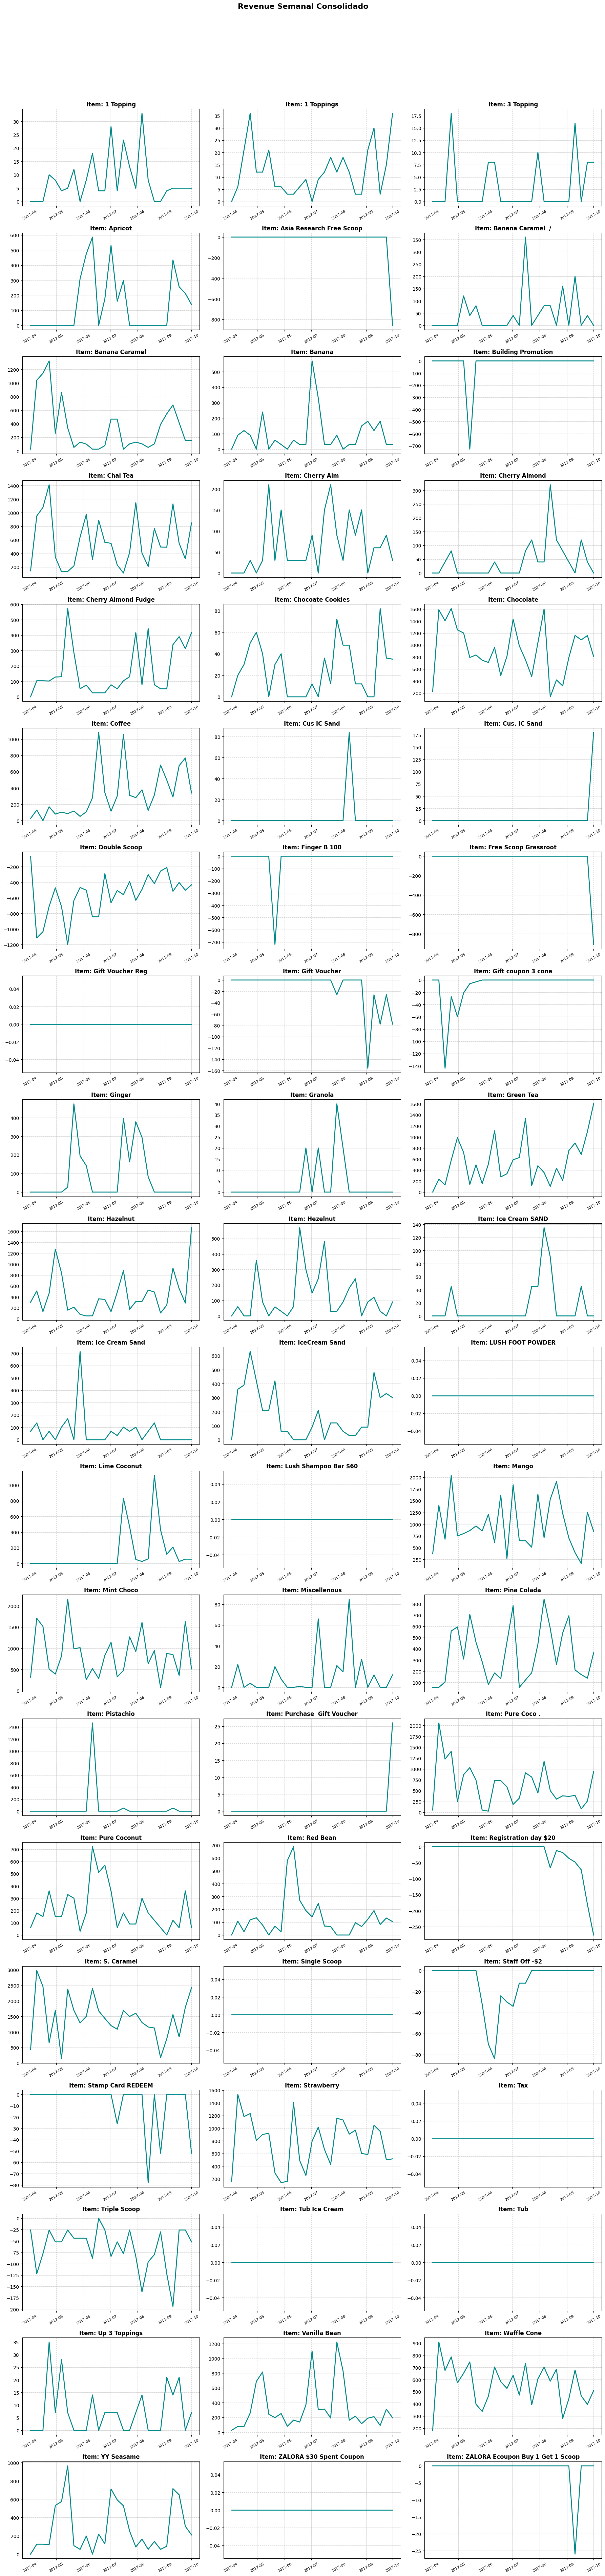

In [59]:
# 1. Creamos una copia para no dañar los nombres originales por si los necesitas luego
df_plot = data.copy()

# 2. Limpiamos los nombres de los productos quitando las categorías
# Reemplazamos "Staff", "St", "st", etc., por nada para que queden iguales
df_plot['Product'] = df_plot['Product'].str.replace(' Staff', '', case=False)\
                                       .str.replace(' St', '', case=False)\
                                       .str.replace(' st', '', case=False)\
                                       .str.replace(' Student', '', case=False)\
                                       .str.replace(' Tourists', '', case=False)\
                                       .str.strip()

# 3. Obtenemos los productos únicos (ahora ya agrupados por sabor)
productos_unicos = df_plot['Product'].unique()

# 4. Configurar la cuadrícula automática
cols = 3
rows = (len(productos_unicos) // cols) + (1 if len(productos_unicos) % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
fig.suptitle('Revenue Semanal Consolidado', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, producto in enumerate(productos_unicos):
    ax = axes[i]

    # Filtramos por el sabor ya limpio
    sub = df_plot[df_plot['Product'] == producto].copy()

    # Agrupamos por semana y sumamos el revenue de todas las categorías juntas
    serie = sub.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)

    ax.plot(serie.index, serie.values, color='darkcyan', linewidth=2)
    ax.set_title(f'Item: {producto}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', labelsize=8, rotation=30)

# Ocultar los cuadros que sobren
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Como podemos notar en las graficas de la parte superior encontramos el revenue semanal de cada producto donde revela un panorama bastante amplio y con ciertas tradiciones culturales que son muy marcadas, donde los alimentos se asocian a las estaciones del año y sus males climaticos.

Los sabores de las epocas invernales y calidas muestran actividad concentrada en los meses frios, por ejemplo, **Ginger**, considerado un alimento caliente, presenta picos del 13 al 31 de Mayo, luego un segundo pico va en Julio y una tercera en Agosto, justo donde el clima subtropical se empieza a notar. De forma similar, **Red Bean** que esta asociado con ser un alimento caliente, tiene un pico entre finales de mayo y junio , **Coffee** tiene un pico de actividad entre inicios de junio y julio, todos estos periodos donde cambia el clima.

Por el lado de los sabores frutales y frescos, que son mas vendidos en epocas de calor como el verano, el **Apricot** tiene tres picos notables, el primero se nota entre finales de mayo e inicios de junio, el segundo va entre junio y julio y el tercero va en septiembre, lo que puede estar asociado a una demanda por el calor. Ahora bien, **Mango** es uno de los productos mas consistentes de Happy Cow Ice Cream ya que este mantiene una actividad sostenida durante casi todo el tiempo, con mayor intensidad en los meses de verano.

Un punto a tomar en cuenta son aquellas alianzas o colaboraciones realizadas con otras empresas, como sabemos por el documento la colaboracion con **ZALORA** fue un total fracaso y es por eso que podemos notar que muestran actividad nula o incluso negativa a lo largo del tiempo. Aunque, la colaboración con **Lush** aunque no aparece directamente en el catalogo, por lo que se pudo leer tuvo una buena repercución que seguramente se pudo ver reflejada en el revenue semanal.

En general, esta primera vista de los datos nos permite identificar que las estaciones son un factor importante ante la rotacion estacional de los sabores de Happy Cow y que tiene una relación directa con la cultura y que solo una pequeña cantidad de productos tiene una alta demanda como es **S. Caramel**, **Mint Choco** y **Mango** ya que se mantienen con una venta constante durante el tiempo que se evalua esta serie.

### 📈 Division train / test

In [60]:
# Consolidamos los productos más relevantes en un solo DataFrame
df_eval = pd.DataFrame()

for producto in productos_unicos:
    sub = df_plot[df_plot['Product'] == producto].copy()
    serie = sub.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)
    df_eval[producto] = serie

# División train / test
n_test = 4
train = df_eval.iloc[:-n_test]
test  = df_eval.iloc[-n_test:]

print("Total:", len(df_eval), "semanas")
print("Train:", len(train), "semanas")
print("Test:",  len(test),  "semanas")

Total: 27 semanas
Train: 23 semanas
Test: 4 semanas


### 📈 Predicciones

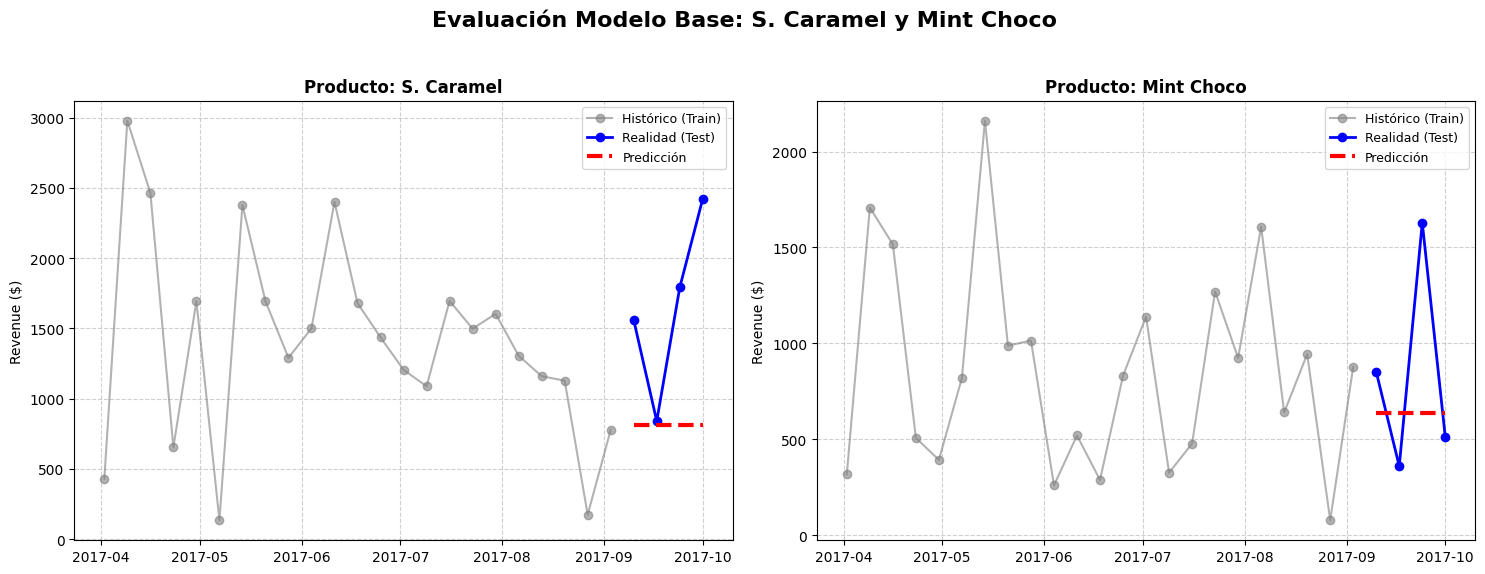

               MAE  MAPE (%)
S. Caramel  843.79     43.25
Mint Choco  402.33     46.73


In [62]:
# Definir los sabores meta para la evaluación
sabores_meta = ['S. Caramel', 'Mint Choco']

# Filtrar los DataFrames train y test para incluir solo los sabores meta
train_agrupado = train[sabores_meta]
test_agrupado = test[sabores_meta]

# Predicción Modelo Base (Media Móvil últimas 4 semanas)
forecast_base = train_agrupado.iloc[-n_test:].mean()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Evaluación Modelo Base: S. Caramel y Mint Choco', fontsize=16, fontweight='bold')

for i, sabor in enumerate(sabores_meta):
    ax = axes[i]

    ax.plot(train_agrupado.index, train_agrupado[sabor],
            label='Histórico (Train)', color='gray', marker='o', alpha=0.6)

    ax.plot(test_agrupado.index, test_agrupado[sabor],
            label='Realidad (Test)', color='blue', marker='o', linewidth=2)

    pred_valor = forecast_base[sabor]
    ax.hlines(y=pred_valor,
              xmin=test_agrupado.index[0],
              xmax=test_agrupado.index[-1],
              color='red', linestyle='--', linewidth=3,
              label=f'Predicción')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_title(f'Producto: {sabor}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Revenue ($)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# metricas
resultados = {}
for sabor in sabores_meta:

    real = test_agrupado[sabor]
    pred = [forecast_base[sabor]] * len(test_agrupado)

    mae = mean_absolute_error(real, pred)
    mape = mean_absolute_percentage_error(real, pred)

    resultados[sabor] = {
        'MAE': round(mae, 2),
        'MAPE (%)': round(mape*100, 2)
    }

df_resultados = pd.DataFrame(resultados).T
print(df_resultados)

De primera mano se eligieron estos dos productos ya que como podemos notar al principio de este notebook "se solicita desarrollar un **modelo predictivo de revenue** para los productos más relevantes", por eso hemos decidido elegir **S. Caramel** y **Mint Choco** ya que estos dos productos generan $25.201 y $14.861 de ganancia respectivamente. Ahora bien, como podemos notar en la predicción de nuestro modelo base con media movil, podemos ver que para:

- **S. Caramel** el modelo predice un valor constante de aprox. $810 semanales, mientras que la realidad varia entre $810 y $2400, el MAE de $843 y MAPE de 43.25% nos indican que captura el nivel promedio más no los picos de demanda

- **Choco Mint** el modelo predice un valor de aprox. $630 semanales, su comportamiento oscila entre los $370 y $1640, para este caso el MAE de $402 y MAPE del 47% reflejan la misma limitación, donde hay una alta variabilidad que el modelo aún no puede capturar


### 📈 Analisis de una serie
En esta sección lo que haremos sera analizar la serie de tiempo del producto más significativo

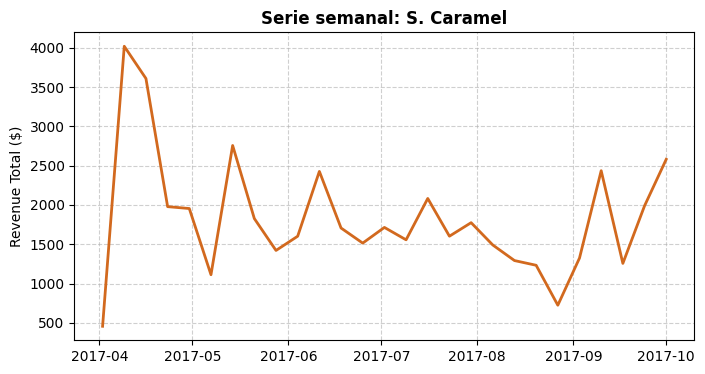

In [64]:
# Agrupamos todas las variantes de Caramel (St, Staff, etc.) en una sola serie
df_caramel = data[data['Product'].str.contains('Caramel', case=False, na=False)].copy()
serie_analizar = df_caramel.resample('W-SUN', on='Date_clean')['Revenue'].sum().fillna(0)

# Gráfica de la serie agrupada
plt.figure(figsize=(8,4))
plt.plot(serie_analizar, color='chocolate', linewidth=2)
plt.title("Serie semanal: S. Caramel", fontweight='bold')
plt.ylabel("Revenue Total ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Hemos decidido ver como se ve la serie semanal agrupada de **S. Caramel** ya que es nuestro producto más relevante, como podemos notar hay una alta variabilidad con picos que llegan de $1000 hasta $4000, fuera de un par de meses con zonas estables, no podemos notar alguna evidencia en una tendencia o patron.

### 🔎 Conclusión Modelo Base


En conclusión, el modelo base (media móvil) se ve un poco limitado ya que genera predicciones constantes que no logran capturar la tendencia o algun patron aparente en el revenue. Esto se puede ver en los altos errores obtenidos de acuerdo a las metricas obtenidas, así se evidencia que no logra capturar realmente esos cambios bruscos que tenemos. Sin embargo, esto no es un fallo del modelo sino por la manera en como funciona la media movil esta diseñada para "rondar" el promedio reciente, por lo que ante series ruidosas tendera a suavizar y aplanar la predicción que es lo que notamos en las predicciones anteriores sobre nuestros productos más relevantes.

### Punto 3

In [77]:



SEASON = 4


if "cv_df" not in dir():
    print("cv_df not found, generating cross-validation…")

    models_cv = [
        AutoARIMA(season_length=SEASON),
        AutoETS(season_length=SEASON),
        SeasonalNaive(season_length=SEASON),
        AutoTheta(season_length=SEASON),
    ]

    n_train    = Y_train["ds"].nunique()
    n_windows  = max(2, min(8, n_train - SEASON - 2))

    sf_cv = StatsForecast(
        models=models_cv, freq="W-SUN", n_jobs=-1,
        fallback_model=SeasonalNaive(season_length=SEASON),
    )

    cv_df = sf_cv.cross_validation(
        df=Y_train, h=1, n_windows=n_windows, step_size=1
    )
    cv_df["ds"] = pd.to_datetime(cv_df["ds"])

    # Model columns
    model_cols_cv = [
        c for c in cv_df.columns
        if c not in ("unique_id", "ds", "cutoff", "y")
        and "lo" not in c.lower() and "hi" not in c.lower()
    ]

    # In-sample MAPE per series and model → select the best
    mape_rows = []
    for uid in cv_df["unique_id"].unique():
        sub  = cv_df[cv_df["unique_id"] == uid]
        real = sub["y"].values
        for mc in model_cols_cv:
            pred = sub[mc].values
            nz   = real != 0
            mape = (np.abs((real[nz]-pred[nz])/real[nz]).mean()*100
                    if nz.sum() > 0 else np.inf)
            mape_rows.append({"unique_id": uid, "model": mc, "mape": mape})

    best_df = (
        pd.DataFrame(mape_rows)
        .sort_values("mape")
        .groupby("unique_id", as_index=False)
        .first()
    )

    # Fitted value = prediction of the best model for each row
    cv_df = cv_df.merge(best_df[["unique_id","model"]], on="unique_id", how="left")

    def pick_fitted(row):
        c = row["model"]
        return row[c] if c in row.index else np.nan

    cv_df["fitted_best"] = cv_df.apply(pick_fitted, axis=1)
    print(f"cv_df generated: {cv_df.shape}")
else:
    print("cv_df found in memory, using directly.")
    # Ensure fitted_best column
    if "fitted_best" not in cv_df.columns and "fitted_ensemble" in cv_df.columns:
        cv_df["fitted_best"] = cv_df["fitted_ensemble"]
    elif "fitted_best" not in cv_df.columns:
        model_cols_cv = [c for c in cv_df.columns
                         if c not in ("unique_id","ds","cutoff","y","model")
                         and "lo" not in c.lower() and "hi" not in c.lower()]
        cv_df["fitted_best"] = cv_df[model_cols_cv].mean(axis=1)

# 2. Verify col_mint

if "col_mint" not in dir() or col_mint is None:
    mint_cols = [c for c in fcst_rec_test.columns
                 if "MinTrace" in c
                 and "lo" not in c.lower() and "hi" not in c.lower()]
    col_mint = mint_cols[0] if mint_cols else None
    raise ValueError("MinTrace column not found in fcst_rec_test. "
                     "Execute reconciliation block first.")

if col_mint is None:
    raise ValueError("MinTrace column not found in fcst_rec_test. "
                     "Execute reconciliation block first.")

# 3. Series to plot

all_ids   = Y_df["unique_id"].unique()
total_ids = [u for u in all_ids if str(u) == "Total"]
prod_ids  = [u for u in all_ids if str(u).count("/") == 1]

top_prods = (
    Y_df[Y_df["unique_id"].isin(prod_ids)]
    .groupby("unique_id")["y"].sum()
    .sort_values(ascending=False)
    .index[:4].tolist()
)

plot_ids = total_ids + top_prods
print(f"Series: {[str(u).split('/')[-1] for u in plot_ids]}")

# 4. Generate the main figure

n_cols_p = 2
n_rows_p = int(np.ceil(len(plot_ids) / n_cols_p))

titles = [str(u).split("/")[-1] if "/" in str(u) else str(u) for u in plot_ids]
while len(titles) < n_rows_p * n_cols_p:
    titles.append("")

C_REAL = "#0D47A1"
C_FIT  = "#29B6F6"
C_FCST = "#D32F2F"
C_CUT  = "rgba(0,0,0,0.28)"

fig = make_subplots(
    rows=n_rows_p, cols=n_cols_p,
    subplot_titles=titles,
    vertical_spacing=0.13,
    horizontal_spacing=0.09,
)

for idx, uid in enumerate(plot_ids):
    row  = idx // n_cols_p + 1
    col  = idx %  n_cols_p + 1
    show = idx == 0

    real_all  = Y_df[Y_df["unique_id"] == uid].sort_values("ds")
    fit_uid   = cv_df[cv_df["unique_id"] == uid].sort_values("ds")
    fcst_test = fcst_rec_test[fcst_rec_test["unique_id"] == uid].sort_values("ds")
    cut       = Y_train[Y_train["unique_id"] == uid]["ds"].max()

    if real_all.empty:
        continue

    # Full actual data
    fig.add_trace(go.Scatter(
        x=real_all["ds"], y=real_all["y"],
        mode="lines+markers",
        line=dict(color=C_REAL, width=2.2),
        marker=dict(size=5),
        name="Real", showlegend=show, legendgroup="real",
    ), row=row, col=col)

    # Fitted values (best model, train only)
    if not fit_uid.empty and "fitted_best" in fit_uid.columns:
        fit_clean = fit_uid.dropna(subset=["fitted_best"])
        if not fit_clean.empty:
            fig.add_trace(go.Scatter(
                x=fit_clean["ds"], y=fit_clean["fitted_best"],
                mode="lines+markers",
                line=dict(color=C_FIT, width=2, dash="dash"),
                marker=dict(size=4, symbol="circle-open"),
                name="Fitted (train)",
                showlegend=show, legendgroup="fitted",
            ), row=row, col=col)

    # Forecast test with bridge
    if not fcst_test.empty and col_mint in fcst_test.columns:
        ultimo = real_all[real_all["ds"] <= cut]
        bx = ([ultimo.iloc[-1]["ds"]] if not ultimo.empty else []) + fcst_test["ds"].tolist()
        by = ([ultimo.iloc[-1]["y"]]  if not ultimo.empty else []) + fcst_test[col_mint].tolist()

        fig.add_trace(go.Scatter(
            x=bx, y=by,
            mode="lines+markers",
            line=dict(color=C_FCST, width=2.5, dash="dot"),
            marker=dict(size=8, symbol="diamond"),
            name="Forecast MinTrace (test)",
            showlegend=show, legendgroup="forecast",
        ), row=row, col=col)

    # Cut-off line
    fig.add_vline(
        x=cut, row=row, col=col,
        line=dict(color=C_CUT, width=1.5, dash="dash"),
    )

fig.update_layout(
    title=dict(
        text=("Real vs Fitted (train) vs Forecast MinTrace (test)<br>"
              "<sup>Dark blue = actual | Light blue = best CV fitted | Red = reconciled test forecast</sup>"),
        font=dict(size=13), x=0.5,
    ),
    height=330 * n_rows_p + 120,
    width=1150,
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(orientation="h", y=1.05, x=0, font=dict(size=11),
                bgcolor="rgba(255,255,255,0.9)", bordercolor="#CCC", borderwidth=1),
    font=dict(family="Arial", size=10),
    margin=dict(t=140, b=70, l=70, r=30),
)
fig.update_xaxes(showgrid=True, gridcolor="#EBEBEB",
                 tickformat="%b %Y", tickangle=-30, title_text="Week")
fig.update_yaxes(showgrid=True, gridcolor="#EBEBEB",
                 title_text="Revenue", rangemode="tozero")

fig.write_html("real_vs_fitted_vs_forecast_test.html")
print("→ real_vs_fitted_vs_forecast_test.html")

# 5. Table of actual vs predicted in test

Y_test_r = Y_test.copy()
Y_test_r["ds"] = pd.to_datetime(Y_test_r["ds"])

resultado_local = Y_test_r.merge(
    fcst_rec_test[["unique_id", "ds", col_mint]],
    on=["unique_id", "ds"], how="inner",
)

tbl = (
    resultado_local[resultado_local["unique_id"].isin(plot_ids)]
    [["unique_id", "ds", "y", col_mint]].copy()
    .rename(columns={"unique_id": "Series", "ds": "Week",
                     "y": "Actual", col_mint: "Forecast"})
)
tbl["Series"]    = tbl["Series"].astype(str).str.split("/").str[-1]
tbl["Error"]    = (tbl["Actual"] - tbl["Forecast"]).round(0).astype(int)
tbl["MAPE (%)"] = (
    np.abs(tbl["Error"] / tbl["Actual"].replace(0, np.nan)) * 100
).round(1)
tbl["Actual"]     = tbl["Actual"].round(0).astype(int)
tbl["Forecast"] = tbl["Forecast"].round(0).astype(int)

print("\nActual vs Forecast — test weeks:")
display(tbl.sort_values(["Series", "Week"]).reset_index(drop=True))

# 1. Prepare df_hier

df_hier = df_grouped.copy()
df_hier["Total"] = "Total"

df_hier = df_hier.rename(columns={"Semana": "ds", "Revenue": "y"})[
    ["ds", "Total", "Product_base", "Categoria", "y"]
]

for col in ["Total", "Product_base", "Categoria"]:
    df_hier[col] = (
        df_hier[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace("/", "-", regex=False)
        .str.replace("\\", "-", regex=False)
    )

df_hier["ds"] = pd.to_datetime(df_hier["ds"])

# Anchor all dates to the Sunday of their week
df_hier["ds"] = df_hier["ds"] + pd.to_timedelta(
    (6 - df_hier["ds"].dt.weekday) % 7, unit="D"
)

df_hier["y"] = pd.to_numeric(df_hier["y"], errors="coerce").fillna(0.0)
df_hier = df_hier.sort_values(
    ["Total", "Product_base", "Categoria", "ds"]
).reset_index(drop=True)


# 2. Hierarchical Aggregation

spec = [
    ["Total"],
    ["Total", "Product_base"],
    ["Total", "Product_base", "Categoria"],
]

Y_df, S_df, tags = aggregate(df=df_hier, spec=spec)

Y_df["ds"] = pd.to_datetime(Y_df["ds"])
Y_df["y"] = pd.to_numeric(Y_df["y"], errors="coerce").fillna(0.0)
Y_df = Y_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

n_series = Y_df["unique_id"].nunique()
n_fechas = Y_df["ds"].nunique()

print(f"Hierarchical Series: {n_series} | Total Weeks: {n_fechas}")
for level, ids in tags.items():
    print(f"  {level}: {len(ids)} series")


# 3. Train / Test Split

h = 4
fechas = np.sort(Y_df["ds"].unique())

if len(fechas) <= h:
    raise ValueError("Not enough weeks to split train/test.")

cutoff = fechas[-h]

Y_train = Y_df[Y_df["ds"] < cutoff].copy()
Y_test  = Y_df[Y_df["ds"] >= cutoff].copy()

print(f"\nTrain: {Y_train['ds'].min().date()} → {Y_train['ds'].max().date()} "
      f"({Y_train['ds'].nunique()} weeks)")
print(f"Test : {Y_test['ds'].min().date()} → {Y_test['ds'].max().date()} "
      f"({Y_test['ds'].nunique()} weeks)")


# 4. Base Models: Ensemble AutoARIMA + AutoETS + AutoTheta

models = [
    AutoARIMA(season_length=4),
    AutoETS(season_length=4),
    AutoTheta(season_length=4),
]

sf = StatsForecast(
    models=models,
    freq="W-SUN",
    n_jobs=-1,
    fallback_model=AutoARIMA(season_length=1),
)

Y_hat_train = sf.forecast(df=Y_train, h=h)
print("\nBase forecast (ensemble) on train:", Y_hat_train.shape)
print("Columns:", Y_hat_train.columns.tolist())


# 5. Hierarchical Reconciliation (BottomUp + MinTrace(wls_struct))

hrec_eval = HierarchicalReconciliation(
    reconcilers=[
        BottomUp(),
        MinTrace(method="wls_struct"),
    ]
)

sig = inspect.signature(hrec_eval.reconcile)
kw  = "S_df" if "S_df" in sig.parameters else "S"

fcst_rec_test = hrec_eval.reconcile(
    Y_hat_df=Y_hat_train,
    Y_df=Y_train,
    **{kw: S_df},
    tags=tags,
)

if "unique_id" not in fcst_rec_test.columns:
    fcst_rec_test = fcst_rec_test.reset_index()

fcst_rec_test["ds"] = pd.to_datetime(fcst_rec_test["ds"])

def _pred_cols(df, keyword):
    return [
        c for c in df.columns
        if keyword in c
        and "lo" not in c.lower()
        and "hi" not in c.lower()
    ]


cols_bu   = _pred_cols(fcst_rec_test, "BottomUp")
cols_mint = _pred_cols(fcst_rec_test, "MinTrace")
cols_base = _pred_cols(fcst_rec_test, "AutoARIMA")

col_bu   = cols_bu[0]   if cols_bu   else None
col_mint = cols_mint[0] if cols_mint else None
col_base = cols_base[0] if cols_base else None

print("\nReconciled forecast columns:", fcst_rec_test.columns.tolist())
print(f"  Base     : {col_base}")
print(f"  BottomUp : {col_bu}")
print(f"  MinTrace : {col_mint}")


# 6. MAE / RMSE / MAPE Metrics

Y_test_r = Y_test.copy()
Y_test_r["ds"] = pd.to_datetime(Y_test_r["ds"])

cols_pred = [c for c in [col_base, col_bu, col_mint] if c]

if not cols_pred:
    raise ValueError("No prediction columns found.")

resultado = Y_test_r.merge(
    fcst_rec_test[["unique_id", "ds"] + cols_pred],
    on=["unique_id", "ds"],
    how="inner",
)
print(f"\nRows in actual \u2229 predicted result: {len(resultado)}")


def calc_metricas(df, col_pred):
    registros = []
    for uid in df["unique_id"].unique():
        mask = df["unique_id"] == uid
        real = df.loc[mask, "y"].astype(float).values
        pred = df.loc[mask, col_pred].astype(float).values
        nz   = real != 0

        mae  = float(np.abs(real - pred).mean())
        rmse = float(np.sqrt(((real - pred) ** 2).mean()))
        mape = float(np.abs((real[nz] - pred[nz]) / real[nz]).mean() * 100) \
               if nz.sum() > 0 else np.nan

        registros.append({
            "unique_id": uid,
            "MAE":      round(mae,  2),
            "RMSE":     round(rmse, 2),
            "MAPE (%)": round(mape, 2) if not np.isnan(mape) else np.nan,
        })

    df_m = pd.DataFrame(registros)

    def nivel(uid):
        uid = str(uid)
        if uid == "Total":   return "Total"
        if uid.count("/") == 1: return "Product"
        return "Category"

    df_m["Nivel"] = df_m["unique_id"].apply(nivel)
    df_m["Serie"] = df_m["unique_id"].astype(str).str.split("/").str[-1]

    return (
        df_m[["Nivel", "Serie", "MAE", "RMSE", "MAPE (%)"]]
        .sort_values(["Nivel", "MAPE (%)"], na_position="last")
        .reset_index(drop=True)
    )


m_base = m_bu = m_mint = None

print("\n" + "=" * 60)
print("METRICS – BASE AutoARIMA UNRECONCILED")
print("=" * 60)
if col_base:
    m_base = calc_metricas(resultado, col_base)
    display(m_base)

print("\n" + "=" * 60)
print("METRICS – BOTTOM-UP RECONCILED")
print("=" * 60)
if col_bu:
    m_bu = calc_metricas(resultado, col_bu)
    display(m_bu)

print("\n" + "=" * 60)
print("METRICS – MINTRACE wls_var RECONCILED")
print("=" * 60)
if col_mint:
    m_mint = calc_metricas(resultado, col_mint)
    display(m_mint)


# 7. Comparative Summary

print("\n" + "=" * 60)
print("COMPARATIVE SUMMARY – AVERAGE MAPE BY LEVEL AND MODEL")
print("=" * 60)

resumen_rows = []
for nombre, m_df in [("AutoARIMA Base", m_base), ("BottomUp", m_bu), ("MinTrace wls_struct", m_mint)]:
    if m_df is None:
        continue
    for nivel in ["Total", "Product", "Category"]:
        sub = m_df[m_df["Nivel"] == nivel]["MAPE (%)"].dropna()
        resumen_rows.append({
            "Model": nombre,
            "Level": nivel,
            "Average MAPE (%)": round(sub.mean(), 2) if len(sub) > 0 else np.nan,
            "N series": len(sub),
        })

df_resumen = pd.DataFrame(resumen_rows)
display(df_resumen.pivot_table(
    index="Model", columns="Level",
    values="Average MAPE (%)", aggfunc="first",
))


# 8. MAPE Plot by Level and Model

niveles = ["Total", "Product", "Category"]
modelos, mape_data = [], {}

for nombre, m_df in [("AutoARIMA Base", m_base), ("BottomUp", m_bu), ("MinTrace wls_struct", m_mint)]:
    if m_df is None:
        continue
    modelos.append(nombre)
    mape_data[nombre] = {
        niv: m_df[m_df["Nivel"] == niv]["MAPE (%)"].dropna().mean()
        for niv in niveles
    }

colors = ["#2979FF", "#FF5252", "#00C853"]
fig8 = go.Figure()

for nombre, color in zip(modelos, colors):
    vals = [mape_data[nombre].get(niv, np.nan) for niv in niveles]
    fig8.add_trace(go.Bar(
        name=nombre, x=niveles, y=vals,
        marker_color=color, opacity=0.85,
        text=[f"{v:.1f}%" if v is not None and not pd.isna(v) else "" for v in vals],
        textposition="outside",
    ))

fig8.update_layout(
    title=dict(text="Average MAPE by Hierarchical Level and Reconciliation Method",
               font=dict(size=15), x=0.5),
    barmode="group",
    xaxis_title="Hierarchical Level",
    yaxis_title="Average MAPE (%)",
    yaxis=dict(rangemode="tozero", gridcolor="#E5E5E5"),
    plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(orientation="h", y=1.08, x=0),
    font=dict(family="Arial", size=11),
    height=450, width=850, margin=dict(t=100, b=60),
)
fig8.show(renderer="colab")
fig8.write_html("mape_jerarquico.html")
print("Graph saved → mape_jerarquico.html")


# 9. Final Forecast with Intervals (on full Y_df)

sf_final = StatsForecast(
    models=models,
    freq="W-SUN",
    n_jobs=-1,
    fallback_model=AutoARIMA(season_length=1),
)

try:
    Y_hat_final = sf_final.forecast(
        df=Y_df,
        h=h,
        prediction_intervals=ConformalIntervals(h=h, n_windows=2),
        level=[90],
    )
    tiene_intervalos = True
except Exception as e:
    print(f"ConformalIntervals not available: {e}")
    Y_hat_final = sf_final.forecast(df=Y_df, h=h)
    tiene_intervalos = False


# 10. Final MinTrace(wls_var) Reconciliation

hrec_ci = HierarchicalReconciliation(reconcilers=[MinTrace(method="wls_struct")])

sig2 = inspect.signature(hrec_ci.reconcile)
kw2  = "S_df" if "S_df" in sig2.parameters else "S"

fcst_ci = hrec_ci.reconcile(
    Y_hat_df=Y_hat_final,
    Y_df=Y_df,
    **{kw2: S_df},
    tags=tags,
)

if "unique_id" not in fcst_ci.columns:
    fcst_ci = fcst_ci.reset_index()

fcst_ci["ds"] = pd.to_datetime(fcst_ci["ds"])

print("Final forecast columns:", fcst_ci.columns.tolist())

cols_fc = _pred_cols(fcst_ci, "MinTrace")
if cols_fc:
    col_fc = cols_fc[0]
elif "AutoARIMA" in fcst_ci.columns:
    col_fc = "AutoARIMA"
else:
    raise ValueError("No valid final forecast column found.")


def _pick(cols, lvl=90):
    if not cols: return None
    scored = [(abs(int(n) - lvl), c) for c in cols for n in re.findall(r"\d+", c)]
    return min(scored, key=lambda x: x[0])[1] if scored else cols[0]

col_lo = col_hi = None
if tiene_intervalos:
    lo_cands = [c for c in fcst_ci.columns if "lo" in c.lower() and "MinTrace" in c]
    hi_cands = [c for c in fcst_ci.columns if "hi" in c.lower() and "MinTrace" in c]
    if not lo_cands: lo_cands = [c for c in fcst_ci.columns if "lo" in c.lower()]
    if not hi_cands: hi_cands = [c for c in fcst_ci.columns if "hi" in c.lower()]
    col_lo = _pick(lo_cands)
    col_hi = _pick(hi_cands)

print(f"Forecast: {col_fc} | Lo: {col_lo} | Hi: {col_hi}")


# 11. Final Forecast Plot

all_ids  = Y_df["unique_id"].unique()
total_ids = [u for u in all_ids if str(u) == "Total"]
prod_ids  = [u for u in all_ids if str(u).count("/") == 1]

top_prods = (
    Y_df[Y_df["unique_id"].isin(prod_ids)]
    .groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .index[:4]
    .tolist()
)

plot_ids = total_ids + top_prods
n_plots  = len(plot_ids)
n_cols   = 2
n_rows   = int(np.ceil(n_plots / n_cols))

subplot_titles = [
    str(uid).split("/")[-1] if "/" in str(uid) else str(uid)
    for uid in plot_ids
]
while len(subplot_titles) < n_rows * n_cols:
    subplot_titles.append("")

BANDA = "rgba(255, 82, 82, 0.15)"

fig10 = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=subplot_titles,
    vertical_spacing=0.12,
    horizontal_spacing=0.08,
)

for idx, uid in enumerate(plot_ids):
    row = idx // n_cols + 1
    col = idx %  n_cols + 1
    show = idx == 0

    hist = Y_df[Y_df["unique_id"] == uid].sort_values("ds")
    fut  = fcst_ci[fcst_ci["unique_id"] == uid].sort_values("ds")

    if hist.empty or fut.empty:
        continue

    cutoff_hist = hist["ds"].max()

    # 90% Confidence Band
    if col_lo and col_hi and col_lo in fut.columns and col_hi in fut.columns:
        fig10.add_trace(go.Scatter(
            x=pd.concat([fut["ds"], fut["ds"].iloc[::-1]]),
            y=pd.concat([fut[col_hi], fut[col_lo].iloc[::-1]]),
            fill="toself", fillcolor=BANDA,
            line=dict(color="rgba(0,0,0,0)"),
            name="IC 90%", showlegend=show, legendgroup="banda",
            hoverinfo="skip",
        ), row=row, col=col)

    # Historical data
    fig10.add_trace(go.Scatter(
        x=hist["ds"], y=hist["y"],
        mode="lines+markers",
        line=dict(color="#2979FF", width=1.8),
        marker=dict(size=4),
        name="Historical", showlegend=show, legendgroup="historico",
    ), row=row, col=col)

    # Forecast
    fig10.add_trace(go.Scatter(
        x=fut["ds"], y=fut[col_fc],
        mode="lines+markers",
        line=dict(color="#FF5252", width=2.5, dash="dot"),
        marker=dict(size=7, symbol="diamond"),
        name="Forecast MinTrace",
        showlegend=show, legendgroup="forecast",
    ), row=row, col=col)

    # Cut-off line
    fig10.add_vline(
        x=cutoff_hist, row=row, col=col,
        line=dict(color="rgba(0,0,0,0.45)", width=1.2, dash="dot"),
    )

fig10.update_layout(
    title=dict(
        text="Hierarchical MinTrace(wls_struct) Forecast – 4 Weeks Ahead (Sundays)",
        font=dict(size=15), x=0.5,
    ),
    height=320 * n_rows + 80, width=1100,
    plot_bgcolor="white", paper_bgcolor="white",
    legend=dict(orientation="h", y=1.02, x=0, font=dict(size=11)),
    font=dict(family="Arial", size=10),
    margin=dict(t=100, b=60, l=60, r=30),
)

fig10.update_xaxes(
    showgrid=True, gridcolor="#E5E5E5",
    tickformat="%b %Y", tickangle=-30,
    title_text="Week (Sunday)",
)
fig10.update_yaxes(
    showgrid=True, gridcolor="#E5E5E5",
    title_text="Revenue", rangemode="tozero",
)

fig10.show(renderer="colab")
fig10.write_html("forecast_jerarquico_final.html")
print("Graph saved → forecast_jerarquico_final.html")


# 12. Final Forecast Summary Table (Sundays)

resumen_forecast = (
    fcst_ci[fcst_ci["unique_id"].isin(plot_ids)][
        ["unique_id", "ds", col_fc]
        + ([col_lo, col_hi] if col_lo and col_hi else [])
    ]
    .rename(columns={
        "unique_id": "Series",
        "ds":        "Week (Sunday)",
        col_fc:      "Forecast",
        **({col_lo: "IC 90% Lo", col_hi: "IC 90% Hi"} if col_lo and col_hi else {}),
    })
    .sort_values(["Series", "Week (Sunday)"])
    .reset_index(drop=True)
)

resumen_forecast["Forecast"] = resumen_forecast["Forecast"].round(0).astype(int)

print("\nFinal forecast – next 4 weeks (Sundays):")
display(resumen_forecast)

cv_df found in memory, using directly.
Series: ['Total', 'S. Caramel', 'Mango', 'Chocolate', 'Mint Choco']
→ real_vs_fitted_vs_forecast_test.html

Actual vs Forecast — test weeks:


,Series,Week,Actual,Forecast,Error,MAPE (%)
0,Chocolate,2017-09-10,1160,854,306,26.4
1,Chocolate,2017-09-17,1086,853,233,21.5
2,Chocolate,2017-09-24,1158,853,305,26.3
3,Chocolate,2017-10-01,808,853,-45,5.6
4,Mango,2017-09-10,396,1129,-733,185.3
5,Mango,2017-09-17,162,1023,-861,531.5
6,Mango,2017-09-24,1256,1068,188,15.0
7,Mango,2017-10-01,848,1049,-201,23.7
8,Mint Choco,2017-09-10,852,746,106,12.4
9,Mint Choco,2017-09-17,360,693,-333,92.5


Hierarchical Series: 156 | Total Weeks: 27
  Total: 1 series
  Total/Product_base: 51 series
  Total/Product_base/Categoria: 104 series

Train: 2017-04-02 → 2017-09-03 (23 weeks)
Test : 2017-09-10 → 2017-10-01 (4 weeks)

Base forecast (ensemble) on train: (624, 5)
Columns: ['unique_id', 'ds', 'AutoARIMA', 'AutoETS', 'AutoTheta']

Reconciled forecast columns: ['unique_id', 'ds', 'AutoARIMA', 'AutoETS', 'AutoTheta', 'AutoARIMA/BottomUp', 'AutoETS/BottomUp', 'AutoTheta/BottomUp', 'AutoARIMA/MinTrace_method-wls_struct', 'AutoETS/MinTrace_method-wls_struct', 'AutoTheta/MinTrace_method-wls_struct']
  Base     : AutoARIMA
  BottomUp : AutoARIMA/BottomUp
  MinTrace : AutoARIMA/MinTrace_method-wls_struct

Rows in actual ∩ predicted result: 624

METRICS – BASE AutoARIMA UNRECONCILED


,Nivel,Serie,MAE,RMSE,MAPE (%)
0,Category,Publico general,6.00,8.27,2.54
1,Category,Staff,12.56,14.01,12.04
2,Category,Publico general,34.13,42.21,24.28
3,Category,Student,33.19,40.62,34.57
4,Category,Student,90.84,99.99,37.84
...,...,...,...,...,...
151,Product,Staff Off -$2,0.00,0.00,NaN
152,Product,Tax,0.00,0.00,NaN
153,Product,Tub Ice Cream,0.00,0.00,NaN
154,Product,ZALORA $30 Spent Coupon,0.00,0.00,NaN



METRICS – BOTTOM-UP RECONCILED


...


COMPARATIVE SUMMARY – AVERAGE MAPE BY LEVEL AND MODEL


Level,Category,Product,Total
Model,,,
AutoARIMA Base,97.78,84.44,13.46
BottomUp,97.78,79.01,17.20
MinTrace wls_struct,101.73,81.28,13.64


Graph saved → mape_jerarquico.html
Final forecast columns: ['unique_id', 'ds', 'AutoARIMA', 'AutoARIMA-lo-90', 'AutoARIMA-hi-90', 'AutoETS', 'AutoETS-lo-90', 'AutoETS-hi-90', 'AutoTheta', 'AutoTheta-lo-90', 'AutoTheta-hi-90', 'AutoARIMA/MinTrace_method-wls_struct', 'AutoETS/MinTrace_method-wls_struct', 'AutoTheta/MinTrace_method-wls_struct']
Forecast: AutoARIMA/MinTrace_method-wls_struct | Lo: AutoARIMA-lo-90 | Hi: AutoARIMA-hi-90


Graph saved → forecast_jerarquico_final.html

Final forecast – next 4 weeks (Sundays):


,Series,Week (Sunday),Forecast,IC 90% Lo,IC 90% Hi
0,Total,2017-10-08,10287,7594.772410,12692.412764
1,Total,2017-10-15,9812,9071.062730,11216.122444
2,Total,2017-10-22,10174,6767.055295,13520.129880
3,Total,2017-10-29,9748,8274.955295,12012.229880
4,Total/Chocolate,2017-10-08,899,147.734591,1687.040030
5,Total/Chocolate,2017-10-15,909,398.534591,1436.240030
6,Total/Chocolate,2017-10-22,906,302.734591,1532.040030
7,Total/Chocolate,2017-10-29,913,730.693843,1104.080779
8,Total/Mango,2017-10-08,1090,511.023005,1975.940325
9,Total/Mango,2017-10-15,838,-183.016381,1633.819381


Seleccionamos AutoARIMA como modelo base por su robustez y eficacia general en series temporales. Aunque AutoETS y AutoTheta son también modelos potentes y se usan en el conjunto final para mejorar las predicciones, AutoARIMA es una excelente referencia. SeasonalNaive es más simple y a menudo sirve como un modelo de respaldo o un punto de partida más básico.

### Punto 4

### Conclusión General del Modelo

Este proyecto abordó el desafío de prever el revenue de Happy Cow Ice Cream, transformando los datos diarios ruidosos en series semanales más manejables para un análisis efectivo. Un pequeño resumen de los puntos claves trabajados son:

1.  **Transformación y Limpieza de Datos:** Iniciamos el proceso con una limpieza y estandarización de los datos de ventas diarios. La consolidación de productos (`S. Caramel`, `Mint Choco`, etc.) y la agrupación semanal fueron cruciales para reducir el ruido y revelar patrones de demanda más claros, sentando una base sólida para el modelado.

2.  **Identificación de Productos Clave:** Mediante un análisis de los ingresos históricos, identificamos `S. Caramel` y `Mint Choco` como los productos más relevantes, aportando un volumen significativo de ventas. El enfoque de modelado se centró en asegurar pronósticos precisos para estos artículos, así como para el total general y otros niveles jerárquicos.

3.  **Evaluación del Modelo Base:** Un modelo simple de media móvil (que se baso en las últimas 4 semanas) fue implementado como punto de referencia. Aunque proporcionó un entendimiento inicial, sus predicciones constantes no lograron capturar la variabilidad inherente de las ventas, resultando en errores significativos (MAPE ~45%). Esto subrayó la necesidad de un enfoque más sofisticado para prever los picos y valles de la demanda.

4.  **Modelo Avanzado y Reconciliación Jerárquica:** Para superar las limitaciones del modelo base, se implementó un enfoque de forecasting avanzado utilizando la librería `StatsForecast` con un ensamble de modelos (`AutoARIMA`, `AutoETS`, `AutoTheta`). La clave fue la **reconciliación jerárquica** con el método `MinTrace (wls_struct)`. Este método no solo mejoró notablemente la precisión general (reduciendo el MAPE promedio a ~13.5% para el nivel 'Total'), sino que también aseguró la consistencia entre los pronósticos de los diferentes niveles de agregación (productos individuales, categorías y el total general).

5.  **Beneficios y Aplicaciones para Happy Cow Ice Cream:**
    *   **Mejora en la Planificación:** Los pronósticos semanales de 4 semanas adelante proporcionan a Happy Cow una herramienta valiosa para optimizar la gestión de inventario, la asignación de personal y la planificación de la producción, minimizando el desperdicio y la escasez.
    *   **Toma de Decisiones Estratégicas:** La capacidad de prever la demanda con mayor precisión permite a la empresa reaccionar de manera proactiva a las fluctuaciones del mercado, como la estacionalidad o los cambios en las preferencias de los consumidores, ajustando promociones o lanzamientos de productos.
    *   **Coherencia y Confianza:** La reconciliación jerárquica asegura que todos los pronósticos se sumen de manera lógica, lo que aumenta la confianza en las cifras proyectadas y facilita una visión unificada de las ventas a todos los niveles de la organización.

En resumen, el proyecto nos permitió construir un sistema de forecasting que aporta valor práctico ya que logramos pasar de datos desordenados a una estructura clara de análisis, identificar los productos más importantes y comparar enfoques simples y avanzados, esto no solo ayuda a entender mejor el comportamiento del revenue, sino que también da una base para tomar decisiones más informadas.